# Visual Analytics for Trustworthy GeoAI

## Uncertainty in Spatially Explicit Modeling 🖥️

Spatially explicit modeling builds geography into a model. Instead of treating
the whole world the same way, it models each place on its own terms. This is
powerful, but it adds new sources of uncertainty. We look at two of them, and —
because this is a course on **visual analytics** — we *draw* the uncertainty on
maps rather than just reporting numbers:

1. **Spatial inductive bias** — the spatial assumptions we build into a model
   are *choices*. We compare an aspatial model (**Linear Regression**) with a
   spatial model (**GWR**), and use **GeoConformal Prediction** to measure and
   map how confident each one really is.
2. **Spatial transferability** — a model trained in one place often fails when
   moved to another. Using data for the whole US, we split the country by
   **climate region** and visualize how performance changes when a model is
   transferred between regions.

### Setup

The next cells install the packages (needed on Colab) and download the data and
the `geocp` package from the course repository.

In [1]:
# Run once on Google Colab to install the spatial-analysis stack.
import importlib, subprocess, sys
def _ensure(pkgs):
    missing = [p for p in pkgs if importlib.util.find_spec(p.split("==")[0]) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
        print("installed:", ", ".join(missing))
    else:
        print("all packages already available")
_ensure(["geopandas", "mgwr", "libpysal", "esda", "scikit-learn"])

installed: scikit-learn


In [2]:
import os, urllib.request
REPO, BRANCH = "Vezarachan/TUM_Course_SVA_TrustGeoAI", "main"
DATA_FILES = ["data/seattle_sample_3k.csv", "data/king_county.gpkg",
              "data/US_Climate_ERA5_CLIMATE.csv"]
GEOCP_FILES = [f"geocp/{f}" for f in
               ["__init__.py", "core.py", "estimators.py", "results.py", "utils.py", "weights.py"]]
for path in DATA_FILES + GEOCP_FILES:
    if not os.path.exists(path):
        os.makedirs(os.path.dirname(path), exist_ok=True)
        urllib.request.urlretrieve(f"https://raw.githubusercontent.com/{REPO}/{BRANCH}/{path}", path)
        print("downloaded", path)
    else:
        print("cached    ", path)

cached     data/seattle_sample_3k.csv
cached     data/king_county.gpkg
cached     data/US_Climate_ERA5_CLIMATE.csv
cached     geocp/__init__.py
cached     geocp/core.py
cached     geocp/estimators.py
cached     geocp/results.py
cached     geocp/utils.py
cached     geocp/weights.py


In [3]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize

RNG = np.random.default_rng(42)
plt.rcParams.update({"figure.dpi": 110, "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})

def bare(ax):
    """Strip a map axis down to the data."""
    ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])

## Part 1 — Spatial inductive bias

Every spatial model makes an assumption about geography — an **inductive bias**:

| Method | Spatial assumption |
|---|---|
| **Linear Regression** | none — location is ignored, the same rule everywhere |
| **GWR** | the relationship changes smoothly across space (nearby places are similar) |

These are two different *choices*. In this part we fit both to **Seattle house
prices**, then use **GeoConformal Prediction (GeoCP)** to put each model's
uncertainty on the map and compare them.

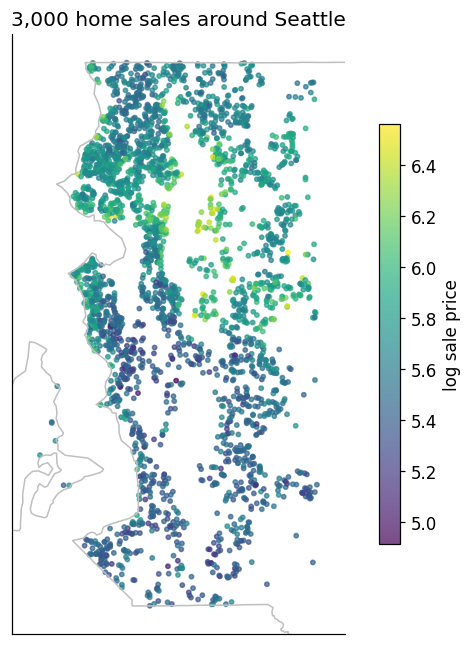

In [4]:
# --- Seattle house sales ---
df = pd.read_csv("data/seattle_sample_3k.csv").drop(columns=["Unnamed: 0"])
FEATURES = ["bathrooms", "sqft_living", "sqft_lot", "grade", "condition", "waterfront", "view", "age"]
X = df[FEATURES].to_numpy(float)
y = df["log_price"].to_numpy(float)              # target: log sale price
coords = df[["UTM_X", "UTM_Y"]].to_numpy(float)  # UTM zone 10N, metres
xy_km = (coords - coords.mean(0)) / 1000.0        # centred km, for spatial kernels

# King County outline, and a helper to zoom maps to where the houses are.
county = gpd.read_file("data/king_county.gpkg", layer="county").to_crs(32610)
_PAD = 3000
X0, X1 = coords[:, 0].min() - _PAD, coords[:, 0].max() + _PAD
Y0, Y1 = coords[:, 1].min() - _PAD, coords[:, 1].max() + _PAD
def seattle_basemap(ax):
    county.boundary.plot(ax=ax, color="0.75", linewidth=1)
    ax.set_xlim(X0, X1); ax.set_ylim(Y0, Y1); bare(ax)

fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=y, cmap="viridis", s=8, alpha=0.7)
plt.colorbar(sc, ax=ax, shrink=0.7, label="log sale price")
ax.set_title("3,000 home sales around Seattle"); seattle_basemap(ax)
plt.tight_layout(); plt.show()

### 1.1 Geography matters

First, does location matter at all? We fit a plain Linear Regression that uses
the house features but **not** the location, and map its errors. If geography
matters, the errors will cluster in space (nearby houses wrong the same way). We
confirm this with **Moran's I**, a measure of spatial clustering.

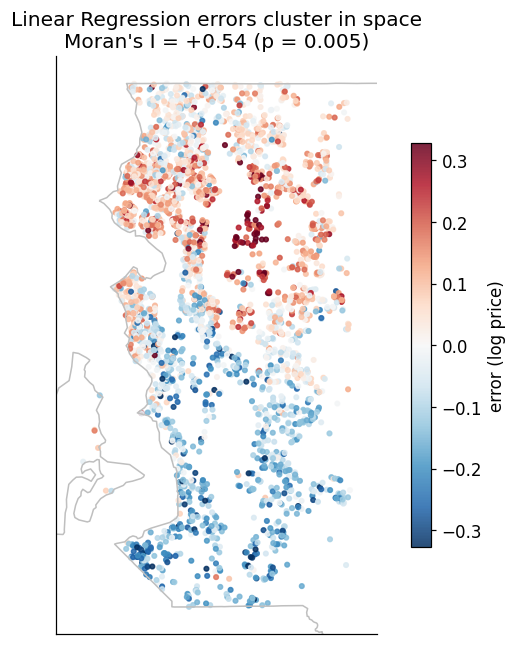

In [5]:
from sklearn.linear_model import LinearRegression
from libpysal.weights import KNN
from esda.moran import Moran

ols = LinearRegression().fit(X, y)
resid = y - ols.predict(X)
w = KNN.from_array(coords, k=8); w.transform = "r"
mi = Moran(resid, w, permutations=199)

fig, ax = plt.subplots(figsize=(6.5, 6))
vlim = np.percentile(np.abs(resid), 98)
sc = ax.scatter(coords[:, 0], coords[:, 1], c=resid, cmap="RdBu_r", vmin=-vlim, vmax=vlim, s=9, alpha=0.85)
plt.colorbar(sc, ax=ax, shrink=0.7, label="error (log price)")
ax.set_title(f"Linear Regression errors cluster in space\nMoran's I = {mi.I:+.2f} (p = {mi.p_sim:.3f})")
seattle_basemap(ax)
plt.tight_layout(); plt.show()

The errors are not random — whole neighbourhoods are too high or too low
together. The aspatial model is missing something, and that something is
*where*. So we bring in a model that is built around location: **GWR**.

### 1.2 A spatial model: GWR

**Geographically Weighted Regression (GWR)** fits a separate regression at every
location using nearby houses. This lets the effect of a feature change across the
city — its inductive bias is exactly *"nearby places behave similarly"*. We map
the local effect of living area; it is clearly not the same everywhere.

(How smooth this map is depends on the **bandwidth** — how many neighbours count
as "local" — which is itself a choice. We fix it here for speed; `mgwr`'s
`Sel_BW` can choose it automatically.)

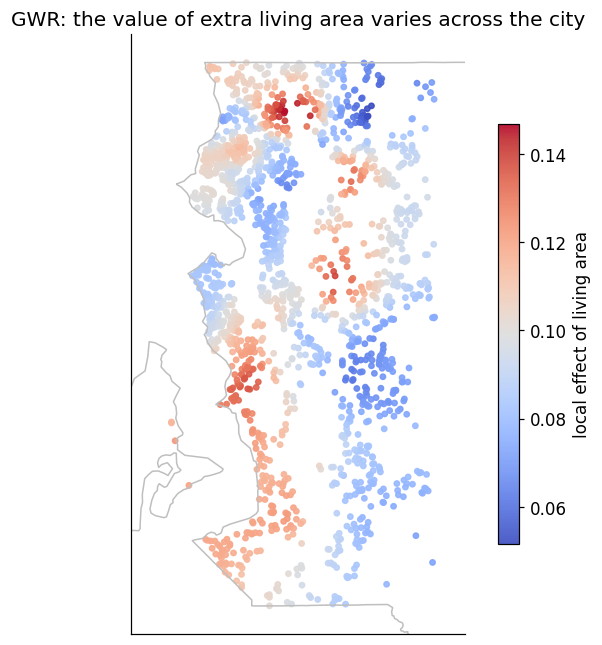

In [6]:
from mgwr.gwr import GWR

# A 60/20/20 split: fit GWR + LR on 'fit', calibrate GeoCP on 'cal', evaluate on 'test'.
n = len(df); order = RNG.permutation(n)
fit_i, cal_i, test_i = order[:int(.6*n)], order[int(.6*n):int(.8*n)], order[int(.8*n):]

GWR_FEATS = ["sqft_living", "grade", "age", "condition", "bathrooms"]
Xg = df[GWR_FEATS].to_numpy(float)
mu, sd = Xg[fit_i].mean(0), Xg[fit_i].std(0)
Xs = (Xg - mu) / sd
ym = y[fit_i].mean()
BW = 200  # adaptive bandwidth (number of neighbours)

gwr_model = GWR(coords[fit_i], (y[fit_i] - ym).reshape(-1, 1), Xs[fit_i], BW,
                fixed=False, kernel="bisquare")
gwr_fit = gwr_model.fit()
b_living = gwr_fit.params[:, GWR_FEATS.index("sqft_living") + 1]

fig, ax = plt.subplots(figsize=(6.5, 6))
sc = ax.scatter(coords[fit_i, 0], coords[fit_i, 1], c=b_living, cmap="coolwarm", s=12, alpha=0.9)
plt.colorbar(sc, ax=ax, shrink=0.7, label="local effect of living area")
ax.set_title("GWR: the value of extra living area varies across the city")
seattle_basemap(ax)
plt.tight_layout(); plt.show()

### 1.3 Comparing uncertainty with GeoConformal Prediction

A better fit is not the whole story — we want to know *how confident* each model
is, and *where*. **GeoConformal Prediction (GeoCP)** turns any model into
prediction intervals: it looks at the model's errors on a calibration set,
weights them by spatial distance to each test point, and returns an interval
whose width is the local uncertainty.

We wrap **both** the Linear Regression and the GWR model in GeoCP (target 90%
coverage) and compare the interval widths they produce.

In [7]:
from geocp import GeoConformalPrediction
from geocp.weights import spatial_kernel_weights

# GeoCP only needs the *predictions* at calibration + test points. We pass row
# indices as the "features" and let predict_f look up precomputed predictions.
sub = np.concatenate([cal_i, test_i])
pred_lr = np.full(n, np.nan);  pred_lr[sub]  = LinearRegression().fit(X[fit_i], y[fit_i]).predict(X[sub])
pred_gwr = np.full(n, np.nan); pred_gwr[sub] = gwr_model.predict(coords[sub], Xs[sub]).predictions.flatten() + ym

def predf(preds):
    return lambda ii: preds[np.asarray(ii).astype(int).ravel()]

def run_geocp(preds, bw_km=6.0):
    wf = spatial_kernel_weights(xy_km[cal_i], bandwidth=bw_km)
    cp = GeoConformalPrediction(predf(preds), cal_i.reshape(-1, 1), y[cal_i], wf, miscoverage_level=0.10)
    return cp.conformalize(test_i.reshape(-1, 1), y[test_i], coord_test=xy_km[test_i])

res_lr, res_gwr = run_geocp(pred_lr), run_geocp(pred_gwr)
for name, r in [("Linear Regression", res_lr), ("GWR", res_gwr)]:
    print(f"{name:18s}: coverage = {r.coverage:.3f}  |  mean interval width = {r.mean_width_finite:.3f}")

Linear Regression : coverage = 0.925  |  mean interval width = 0.464
GWR               : coverage = 0.892  |  mean interval width = 0.290


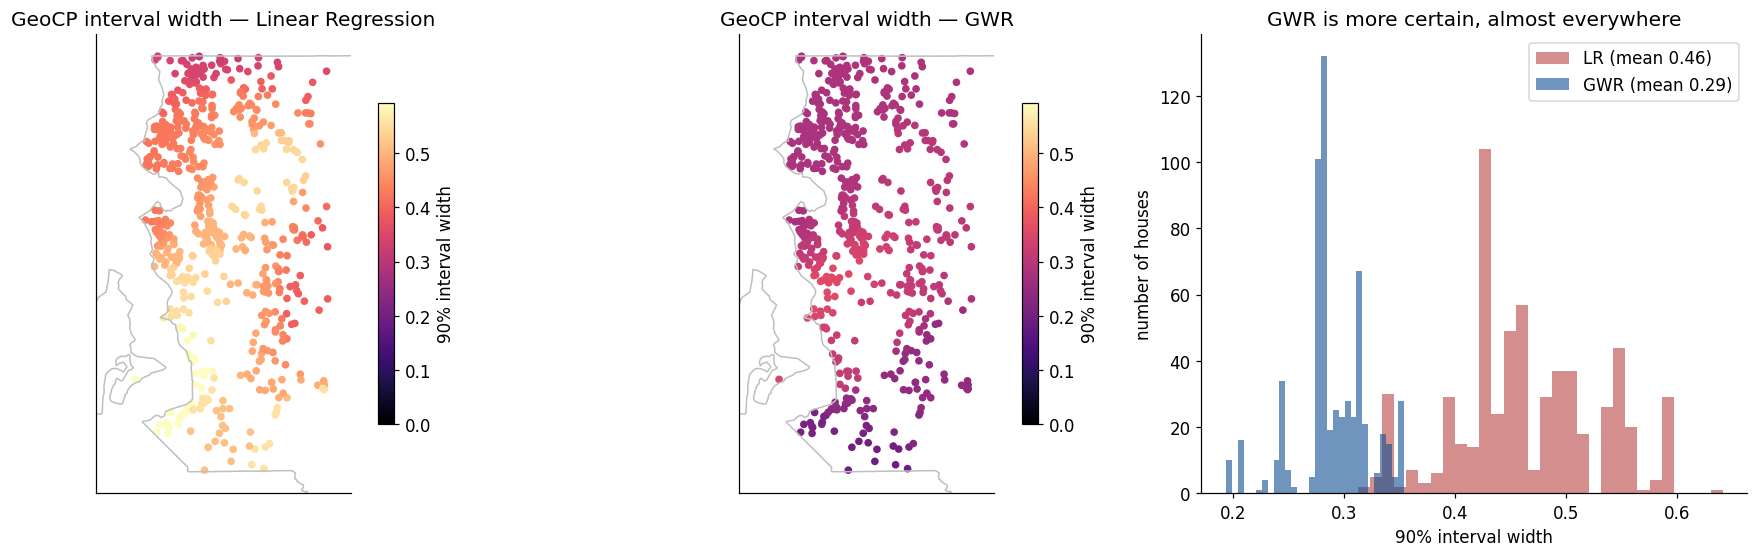

In [8]:
# Visual comparison: where is each model uncertain, and how do the widths differ?
w_lr, w_gwr = 2*res_lr.uncertainty, 2*res_gwr.uncertainty   # full interval widths
fin = np.isfinite(w_lr) & np.isfinite(w_gwr)                # drop any uncertifiable point
ct = coords[test_i][fin]; w_lr, w_gwr = w_lr[fin], w_gwr[fin]
wmax = np.percentile(np.concatenate([w_lr, w_gwr]), 98)

fig, axes = plt.subplots(1, 3, figsize=(17, 5.2))
for ax, wdt, ttl in [(axes[0], w_lr, "Linear Regression"), (axes[1], w_gwr, "GWR")]:
    sc = ax.scatter(ct[:, 0], ct[:, 1], c=wdt, cmap="magma", vmin=0, vmax=wmax, s=16)
    ax.set_title(f"GeoCP interval width — {ttl}"); seattle_basemap(ax)
    fig.colorbar(sc, ax=ax, shrink=0.7, label="90% interval width")

axes[2].hist(w_lr, bins=30, alpha=0.6, label=f"LR (mean {w_lr.mean():.2f})", color="#B64342")
axes[2].hist(w_gwr, bins=30, alpha=0.6, label=f"GWR (mean {w_gwr.mean():.2f})", color="#0F4D92")
axes[2].set_xlabel("90% interval width"); axes[2].set_ylabel("number of houses")
axes[2].set_title("GWR is more certain, almost everywhere"); axes[2].legend()
plt.tight_layout(); plt.show()

Both models reach the promised ~90% coverage, so both are *honest*. But the
spatial model is **more confident**: GWR's intervals are clearly narrower, and
its uncertainty is lower across most of the city. The inductive bias — "nearby
places are similar" — is what buys that extra confidence, and GeoCP lets us
*see* exactly where it pays off.

**Is one model's uncertainty more *uneven* or more *spatially patterned*?**
We can quantify the width maps with two numbers: the **coefficient of variation**
(CV = std / mean — how uneven the widths are) and **Moran's I of the widths**
(how spatially clustered they are).

In [9]:
def width_stats(wdt, xyc):
    cv = wdt.std() / wdt.mean()
    wknn = KNN.from_array(xyc, k=8); wknn.transform = "r"
    mi_w = Moran(wdt, wknn, permutations=99)
    return cv, mi_w.I

cv_lr, miw_lr = width_stats(w_lr, ct)
cv_gwr, miw_gwr = width_stats(w_gwr, ct)
print(f"{'':18s}{'mean width':>12}{'CV (uneven)':>14}{'Moran I (pattern)':>20}")
print(f"{'Linear Regression':18s}{w_lr.mean():>12.3f}{cv_lr:>14.3f}{miw_lr:>20.3f}")
print(f"{'GWR':18s}{w_gwr.mean():>12.3f}{cv_gwr:>14.3f}{miw_gwr:>20.3f}")

                    mean width   CV (uneven)   Moran I (pattern)
Linear Regression        0.464         0.139               0.934
GWR                      0.290         0.112               0.946


The numbers are revealing — and a little surprising:

* **Unevenness (CV):** GWR is **not** more uneven than LR; if anything its CV is
  slightly *lower*. GWR is both more confident *and* slightly more uniform.
* **Spatial pattern (Moran's I):** **both** width maps are strongly clustered
  (≈ 0.9), almost identically. Nearby houses get similar uncertainty for either
  model.

Why is the pattern so strong for both? Because GeoCP builds each interval from
*spatially weighted* calibration errors, so neighbouring test points share
information by construction — the smooth, clustered look is partly a property of
the method and of where the sales are dense, not only of the model. The choice of
inductive bias (LR vs GWR) mainly shifts the **overall level** of uncertainty
(GWR lower everywhere), not how spatially uneven it is.

> ❓**Question:** GWR gives narrower GeoCP intervals than Linear Regression, at
> the same 90% coverage. Where on the map are the two models most similar in
> uncertainty, and where do they differ most? What does that tell you about when
> the spatial assumption actually helps?

[Your Answer]

## Part 2 — Spatial transferability

We often train a model in one place and use it in another. Does it still work?
To find out at continental scale, we use a US climate dataset
(`US_Climate_ERA5_CLIMATE.csv`): a target value `Y` and nine predictors at tens
of thousands of locations, each labelled with its US **climate region**. We
treat each region as a separate "place" and ask: *if we train here, how well do
we predict there?*

9000 points | 9 climate regions


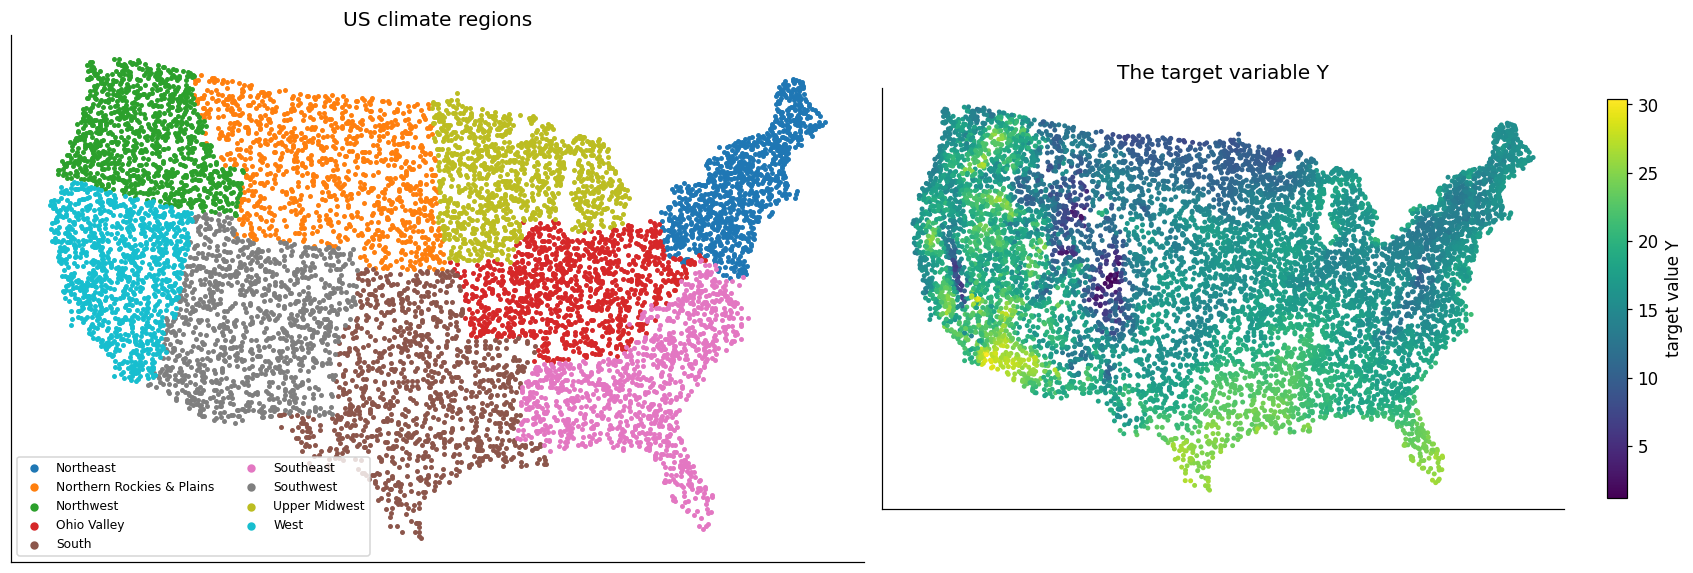

In [10]:
# Load and take a balanced sample (1,000 points per climate region) for speed.
clim = pd.read_csv("data/US_Climate_ERA5_CLIMATE.csv")
clim = clim.groupby("region").sample(n=1000, random_state=1).reset_index(drop=True)
CF = [c for c in clim.columns if c.startswith("X")]
Xc = clim[CF].to_numpy(float)
yc = clim["Y"].to_numpy(float)
region = clim["region"].to_numpy()
REGIONS = sorted(clim["region"].unique())

# Project lon/lat to US Albers equal-area for clean maps.
gc = gpd.GeoDataFrame(clim, geometry=gpd.points_from_xy(clim.lon, clim.lat), crs=4326).to_crs(5070)
cxy = np.c_[gc.geometry.x.values, gc.geometry.y.values] / 1000.0
print(len(clim), "points |", len(REGIONS), "climate regions")

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
cmap = plt.get_cmap("tab10", len(REGIONS))
for k, r in enumerate(REGIONS):
    m = region == r
    axes[0].scatter(cxy[m, 0], cxy[m, 1], s=5, color=cmap(k), label=r)
axes[0].set_title("US climate regions"); bare(axes[0])
axes[0].legend(markerscale=2, fontsize=8, loc="lower left", ncol=2)
sc = axes[1].scatter(cxy[:, 0], cxy[:, 1], c=yc, cmap="viridis", s=5)
fig.colorbar(sc, ax=axes[1], shrink=0.7, label="target value Y")
axes[1].set_title("The target variable Y"); bare(axes[1])
plt.tight_layout(); plt.show()

### 2.1 The region → region transfer matrix

This is the core experiment. We train one model on **each** climate region, then
test it on **every** region. The result is a matrix: row = where we trained,
column = where we tested, colour = how well it did (R²). The **diagonal** is the
easy case (train and test in the same region); everything **off the diagonal** is
a spatial transfer.

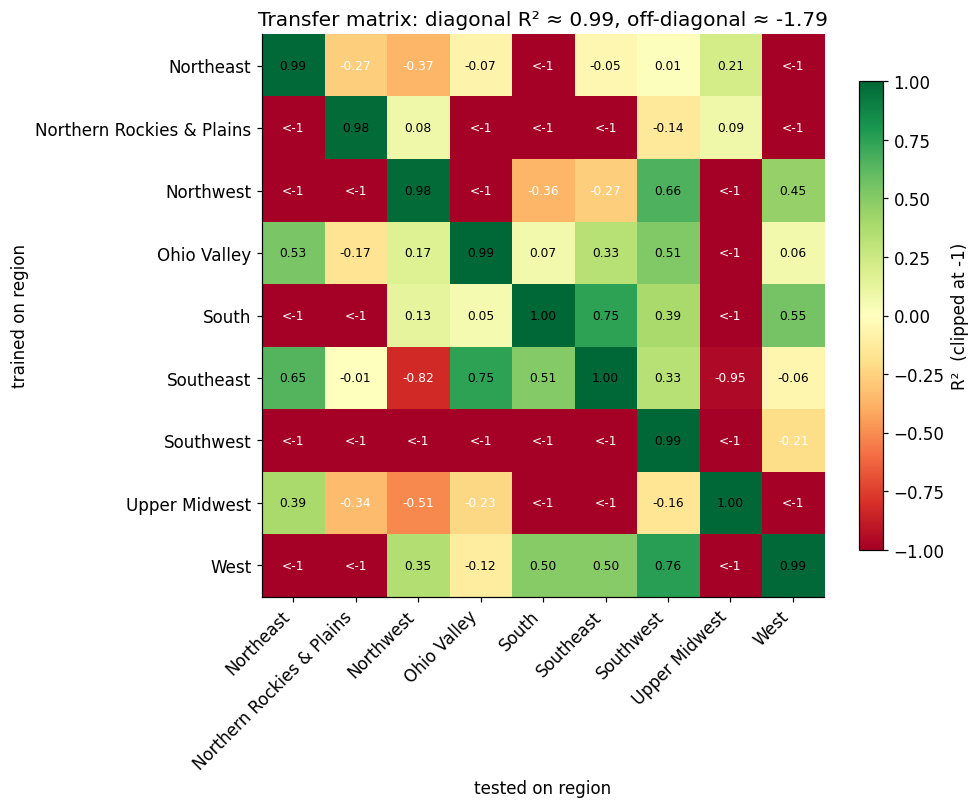

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

models = {r: RandomForestRegressor(n_estimators=120, random_state=0, n_jobs=-1)
                .fit(Xc[region == r], yc[region == r]) for r in REGIONS}
R2 = np.array([[r2_score(yc[region == te], models[tr].predict(Xc[region == te]))
                for te in REGIONS] for tr in REGIONS])

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(R2, cmap="RdYlGn", vmin=-1, vmax=1)   # clip: <0 means worse than the mean
ax.set_xticks(range(len(REGIONS))); ax.set_yticks(range(len(REGIONS)))
ax.set_xticklabels(REGIONS, rotation=45, ha="right"); ax.set_yticklabels(REGIONS)
ax.set_xlabel("tested on region"); ax.set_ylabel("trained on region")
for i in range(len(REGIONS)):
    for j in range(len(REGIONS)):
        v = R2[i, j]
        ax.text(j, i, f"{v:.2f}" if v > -1 else "<-1", ha="center", va="center",
                fontsize=8, color="black" if v > -0.2 else "white")
fig.colorbar(im, ax=ax, shrink=0.8, label="R²  (clipped at -1)")
ax.set_title(f"Transfer matrix: diagonal R² ≈ {np.mean(np.diag(R2)):.2f}, "
             f"off-diagonal ≈ {(R2.sum()-np.trace(R2))/(R2.size-len(REGIONS)):.2f}")
plt.tight_layout(); plt.show()

The diagonal glows green (R² ≈ 0.99): within a region the model is excellent.
Almost everything off the diagonal is yellow-to-red — often **R² below zero**,
meaning the transferred model is *worse than just predicting the average*. A few
pairs survive (climatically similar regions), but most do not. The same model,
moved to a new region, quietly breaks.

### 2.2 Mapping the error of a transferred model

The matrix summarises performance per region; a map shows *where* it breaks.
We train on three different regions in turn and map the prediction error
everywhere. Error stays small inside the training region and grows as we move
away from it.

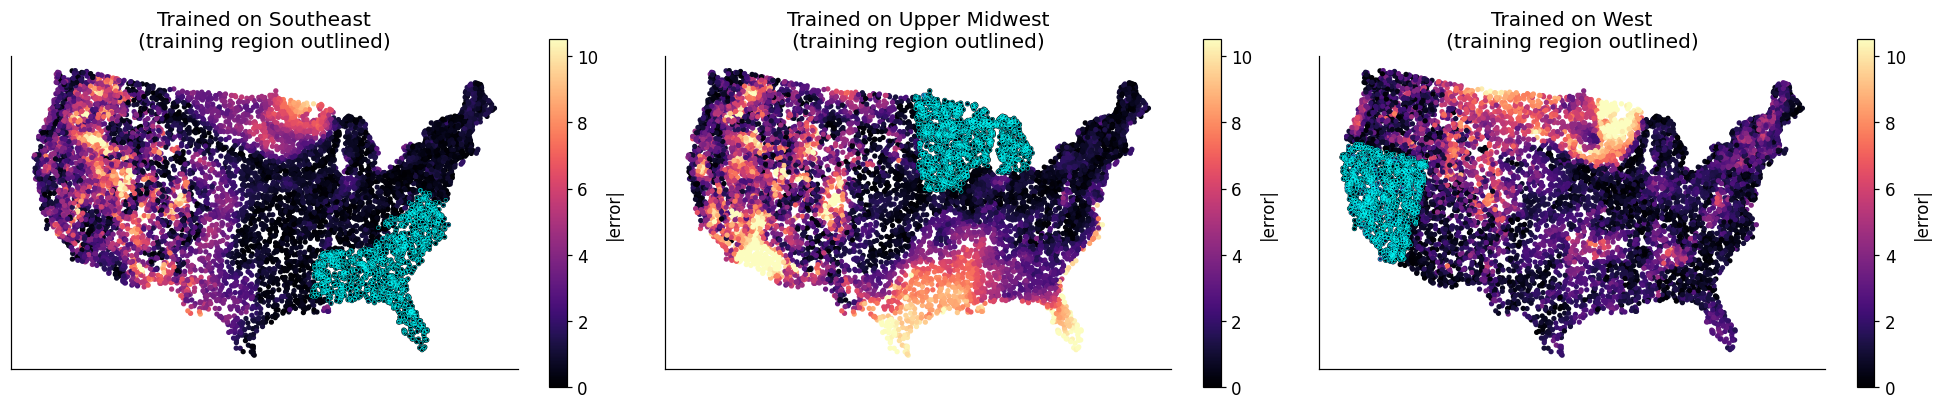

In [12]:
SOURCES = ["Southeast", "Upper Midwest", "West"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
emax = 0
errs = {}
for s in SOURCES:
    errs[s] = np.abs(yc - models[s].predict(Xc))
    emax = max(emax, np.percentile(errs[s], 97))
for ax, s in zip(axes, SOURCES):
    sc = ax.scatter(cxy[:, 0], cxy[:, 1], c=errs[s], cmap="magma", vmin=0, vmax=emax, s=6)
    m = region == s
    ax.scatter(cxy[m, 0], cxy[m, 1], s=6, facecolors="none", edgecolors="cyan", linewidths=0.3)
    ax.set_title(f"Trained on {s}\n(training region outlined)"); bare(ax)
    fig.colorbar(sc, ax=ax, shrink=0.65, label="|error|")
plt.tight_layout(); plt.show()

Each model is accurate (dark) inside its own region and gets worse (bright) with
distance. The error pattern follows climate, not just distance: a model trained
in the humid **Southeast** travels reasonably into nearby eastern regions but
fails in the arid **West**.

### 2.3 Honest uncertainty under transfer: GeoConformal Prediction

Can we at least *know* when a transferred prediction is untrustworthy? We split
the country into **East** (train) and **West** (transfer), and compare standard
Conformal Prediction with **GeoCP**. Standard CP promises 90% coverage but
assumes the test region looks like the calibration region — which fails here.
GeoCP weights calibration errors by spatial distance and **flags points it cannot
certify** (too far from any calibration data).

In [13]:
from geocp import GeoConformalRegressor, GeoConformalPrediction
from geocp.weights import uniform_weights

EAST = {"Northeast", "Southeast", "Ohio Valley", "South", "Upper Midwest"}
train_e = np.isin(region, list(EAST)); test_w = ~train_e
te = np.where(train_e)[0]; RNG.shuffle(te)
half = len(te)//2; fit_e, cal_e = te[:half], te[half:]
m = RandomForestRegressor(n_estimators=150, random_state=0, n_jobs=-1).fit(Xc[fit_e], yc[fit_e])

ALPHA = 0.10
cp_std = GeoConformalPrediction(m.predict, Xc[cal_e], yc[cal_e], uniform_weights(), miscoverage_level=ALPHA)
r_std = cp_std.conformalize(Xc[test_w], yc[test_w], coord_test=cxy[test_w])
geo = GeoConformalRegressor(m.predict, Xc[cal_e], yc[cal_e], cxy[cal_e], bandwidth=300.0, miscoverage_level=ALPHA)
r_geo = geo.geo_conformalize(Xc[test_w], yc[test_w], cxy[test_w])

print(f"target coverage = {1-ALPHA:.0%}  (calibrated on the East, tested on the West)")
print(f"standard CP : coverage = {r_std.coverage:.3f}   (promised 90%)")
print(f"GeoCP       : coverage = {r_geo.coverage:.3f}, {r_geo.frac_infinite:.0%} of the West flagged uncertifiable")

target coverage = 90%  (calibrated on the East, tested on the West)
standard CP : coverage = 0.239   (promised 90%)
GeoCP       : coverage = 0.863, 76% of the West flagged uncertifiable


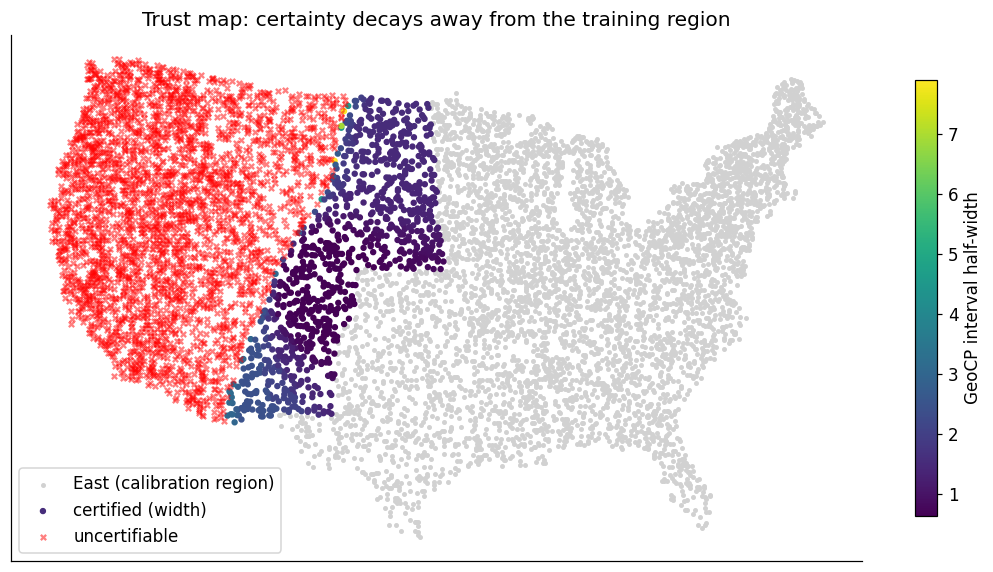

In [14]:
u = r_geo.uncertainty; fin = np.isfinite(u)
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(cxy[train_e, 0], cxy[train_e, 1], s=5, c="0.82", label="East (calibration region)")
sc = ax.scatter(cxy[test_w][fin, 0], cxy[test_w][fin, 1], c=u[fin], cmap="viridis", s=10, label="certified (width)")
ax.scatter(cxy[test_w][~fin, 0], cxy[test_w][~fin, 1], marker="x", c="red", s=12, alpha=0.5, label="uncertifiable")
fig.colorbar(sc, ax=ax, shrink=0.7, label="GeoCP interval half-width")
ax.legend(loc="lower left"); ax.set_title("Trust map: certainty decays away from the training region")
bare(ax)
plt.tight_layout(); plt.show()

Standard CP's 90% promise collapses in the West — it is silently overconfident.
GeoCP cannot *invent* accuracy where there is no nearby training data, but it is
honest: it widens its intervals near the boundary and marks most of the West as
**uncertifiable** (the red ✕). "Uncertifiable" means GeoCP has too little nearby
calibration data to issue a finite 90% interval, so it refuses rather than
guessing. The fix for a new region is always the same: **collect some data
there.**

> ❓**Question:** A colleague trained a model on the eastern US and wants to use
> it in the West, reporting the model's usual confidence intervals. Using the
> transfer matrix (2.1) and the trust map (2.3), what would you warn them about,
> and what would you recommend they check or collect first?

[Your Answer]

## Wrap-up

Spatial modeling does not remove uncertainty — it moves it into the spatial
assumptions we make, and into the gap between where we trained and where we
predict. Visual analytics is how we *find* that uncertainty:

| What we drew | What it revealed |
|---|---|
| **Error map + Moran's I** (1.1) | an aspatial model ignores geography; its errors cluster |
| **GWR coefficient map** (1.2) | the relationship changes across space (spatial heterogeneity) |
| **GeoCP width maps: LR vs GWR** (1.3) | the spatial prior makes the model more confident — visibly, and where |
| **Region → region transfer matrix** (2.1) | a model transferred to another region usually breaks (R² < 0) |
| **Per-source error maps** (2.2) | error grows with climate distance from the training region |
| **GeoCP trust map** (2.3) | where a transferred prediction can — and cannot — be certified |

**Takeaways**

1. A spatial assumption (using GWR vs LR, the bandwidth, the kernel) is a
   *choice*; GeoCP lets us see how much confidence it earns and where.
2. A model that looks perfect in its home region can be worse than useless
   elsewhere — always test transfer with a **spatial / region split**.
3. **GeoConformal Prediction** gives location-aware intervals and, crucially,
   admits where it cannot certify a prediction at all.